In [65]:
import random 
import time
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
from torch.distributions import Normal
from torch.optim.lr_scheduler import LinearLR
from collections import deque

In [66]:
env_id = "MountainCarContinuous-v0"


num_envs = 1
total_timesteps = 1000000

critic_learning_rate = 0.001
actor_learning_rate = 0.0003
gamma = 0.995
video_path = "SAC_Car_videos"
seed = None
batch_size = 256

In [67]:
def make_env(env_id, capture_video, seed=None):
    if capture_video:
        env = gym.make(env_id, render_mode="rgb_array")
        # Episode trigger needed so it records every episode
        env = gym.wrappers.RecordVideo(env, video_path, episode_trigger=lambda episode: True)
    else:
        env = gym.make(env_id)
        
    env = gym.wrappers.RecordEpisodeStatistics(env)
    
    if seed is not None:
        env.action_space.seed(seed)
    return env

In [68]:
# make environments
env = gym.vector.AsyncVectorEnv([
    lambda: make_env(
        env_id,
        capture_video=False,
        seed=seed if seed is None else seed + i) 
    for i in range (num_envs)
])

In [69]:
# Actor takes in current state and produces mean and standard deviation of a normal distribution
class ActorNetwork(nn.Module):
    def __init__(self, env, hidden=256):
        super().__init__()

        obs_dim = env.single_observation_space.shape[0]
        act_dim = env.single_action_space.shape[0]

        self.network = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )

        # Separating outputs for mean and log_sd # Why?
        self.mean_layer = nn.Linear(hidden, act_dim)
        self.log_sd_layer = nn.Linear(hidden, act_dim)

    def forward(self, x):
        x = self.network(x)
        mean = self.mean_layer(x)
        log_sd = self.log_sd_layer(x)
        # clamp so values aren't too large or small
        log_sd = torch.clamp(log_sd, min=-20, max=2)
        return mean, log_sd

# We pass into our Critic neworks
class CriticNetworks(nn.Module):
    def __init__(self, env, hidden=256):
        super().__init__()

        obs_dim = env.single_observation_space.shape[0]
        act_dim = env.single_action_space.shape[0]

        self.network1 = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

        self.network2 = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, obs, actions):
        x = torch.cat([obs, actions], dim=-1)
        q1 = self.network1(x)
        q2 = self.network2(x)
        return q1, q2

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [71]:
Actor = ActorNetwork(env).to(device)
Critic = CriticNetworks(env).to(device)
TargetCritic = CriticNetworks(env).to(device)
TargetCritic.load_state_dict(Critic.state_dict())

<All keys matched successfully>

In [72]:
actor_optim = torch.optim.Adam(Actor.parameters(), lr=actor_learning_rate)
critic_optim = torch.optim.Adam(Critic.parameters(), lr=critic_learning_rate)

In [73]:
def np2torch(a):
    return torch.tensor(a).float().to(device)

In [74]:
# Target entropy is usually set to -dim(action_space)
target_entropy = -env.single_action_space.shape[0] # For Mountain Car, this is -1.0

# We optimize the log of alpha to ensure alpha always remains positive
log_alpha = torch.tensor(np.log(0.1), requires_grad=True, device=device)
alpha_optim = torch.optim.Adam([log_alpha], lr=0.0003)

In [75]:
# Take action specified by ACTOR
# Step environment
# Append step to replay buffer
# Get Q_value from CRITIC by inputting obs, and action sampled from buffer
# Train ACTOR with logs and train CRITIC with soft updates with target network


n_envs = env.num_envs
episode_rewards = np.zeros(n_envs)
episode_returns = []
episode_count = 0
tau = 0.005
entropy = []
buffer = deque(maxlen=200000)

advantage = []
td_targets = []
preds = []

obs, _ = env.reset()

for global_step in range(total_timesteps):

    if global_step < 25000:
        # Force wild, extreme actions to build momentum and find the goal
        # (Assuming env is a vectorized environment)
        actions_np = env.action_space.sample() 
    else:
        # Your normal SAC action sampling
        with torch.no_grad():
            mean, log_sd = Actor(np2torch(obs))
            sd = log_sd.exp()
            normal = Normal(mean, sd)
            x = normal.rsample()
            action = torch.tanh(x)
            actions_np = action.cpu().numpy()
    # with torch.no_grad():
    #     mean, log_sd = Actor(np2torch(obs))
    #     sd = log_sd.exp()
    #     normal = Normal(mean, sd)
    #     x = normal.rsample()
    #     action = torch.tanh(x)
    #     actions_np = action.cpu().numpy()

    next_obs, reward, terminated, truncated, infos = env.step(actions_np)

    buffer_next_obs = next_obs.copy()
    dones = np.logical_or(terminated, truncated)
    episode_rewards += reward

    for i in range(num_envs):
        real_next_obs = buffer_next_obs[i]
        if "final_observation" in infos and infos.get("_final_observation", [False]*num_envs)[i]:
            real_next_obs = infos["final_observation"][i]
            
        buffer.append((obs[i], actions_np[i], reward[i], real_next_obs, terminated[i]))

    for i in range(num_envs):
        if dones[i]:
            ret = episode_rewards[i]
            episode_returns.append(ret)
            episode_count += 1
            print(f"global_step={global_step + i}, episode={episode_count}, episode_return={ret}")
            episode_rewards[i] = 0

    # Training
    if len(buffer) > 25000:
        batch = random.sample(buffer, k=batch_size)
        obs_, actions_, rewards_, buffer_next_obs_, dones_ = zip(*batch)

        tensor_next_obs = np2torch(np.array(buffer_next_obs_))
        tensor_reward = np2torch(np.array(rewards_)).view(-1, 1)
        tensor_obs = np2torch(np.array(obs_))
        tensor_actions = torch.tensor(np.array(actions_), dtype=torch.float32, device=device)
        tensor_dones = torch.tensor(dones_, dtype=torch.float32, device=device).view(-1, 1)

        # Training Critic
        with torch.no_grad():
            # Get "future" action
            f_mean, f_log_sd = Actor(tensor_next_obs)
            sd = f_log_sd.exp()
            normal = Normal(f_mean, sd)
            x = normal.rsample()
            future_action = torch.tanh(x)
            # Get log probs
            log_prob = normal.log_prob(x)
            log_prob -= torch.log(1 - future_action.pow(2) + 1e-6)
            log_prob = log_prob.sum(dim=-1, keepdim=True)

            # Pass "next" state and action into target networks to get our "true" value of the state
            q_value1, q_value2 = TargetCritic(tensor_next_obs, future_action)
            q_value = torch.minimum(q_value1, q_value2)
            # Bellman target
            alpha = log_alpha.exp().detach()
            b_target = tensor_reward + gamma*(1-tensor_dones)*(q_value - alpha*log_prob)

        q_value1, q_value2 = Critic(tensor_obs, tensor_actions)
        
        critic_loss = torch.nn.functional.mse_loss(q_value1, b_target).mean() + torch.nn.functional.mse_loss(q_value2, b_target).mean()

        critic_optim.zero_grad()
        critic_loss.backward()
        critic_optim.step()

        # Train Actor: need to compare to newly updated critic
        mean, log_sd = Actor(tensor_obs)
        sd = log_sd.exp()
        normal = Normal(mean, sd)
        x = normal.rsample()
        action = torch.tanh(x)
        # Get log probs
        log_prob = normal.log_prob(x)
        log_prob -= torch.log(1 - action.pow(2) + 1e-6)
        log_prob = log_prob.sum(dim=-1, keepdim=True)

        for param in Critic.parameters():
            param.requires_grad = False

        q_value1, q_value2 = Critic(tensor_obs, action)
        q_value = torch.minimum(q_value1, q_value2)

        for param in Critic.parameters():
            param.requires_grad = True

        alpha = log_alpha.exp().detach()
        actor_loss = (alpha*log_prob - q_value).mean()


        actor_optim.zero_grad()
        actor_loss.backward()
        actor_optim.step()

        alpha_loss = -(log_alpha.exp() * (log_prob + target_entropy).detach()).mean()

        alpha_optim.zero_grad()
        alpha_loss.backward()
        alpha_optim.step()

        for target_param, local_param in zip(TargetCritic.parameters(), Critic.parameters()):
            target_param.data.copy_(tau * local_param.data + (1.0 - tau) * target_param.data)
    
    obs = next_obs

    if len(episode_returns) > 10 and np.mean(episode_returns[-10:]) >= 90.0:
        print("max reward achieved")
        break

global_step=998, episode=1, episode_return=-34.04027390346242
global_step=1998, episode=2, episode_return=-36.40558824622279
global_step=2998, episode=3, episode_return=-31.12996519358151
global_step=3998, episode=4, episode_return=-33.60965921240248
global_step=4998, episode=5, episode_return=-33.021461340420174
global_step=5998, episode=6, episode_return=-33.541248832575974
global_step=6998, episode=7, episode_return=-33.46634738602144
global_step=7998, episode=8, episode_return=-34.73094052093169
global_step=8998, episode=9, episode_return=-34.63220715234155
global_step=9723, episode=10, episode_return=77.22287021619393
global_step=10723, episode=11, episode_return=-32.732781129669405
global_step=11723, episode=12, episode_return=-34.483619603522044
global_step=12723, episode=13, episode_return=-33.73850402420359
global_step=13723, episode=14, episode_return=-32.90452124243563
global_step=14723, episode=15, episode_return=-32.69715339240946
global_step=15723, episode=16, episode_ret

In [76]:
env.close()

In [77]:
def smooth(x, a=0.1):
    y = [x[0]]
    for xi in x[1:]:
        yi = a * xi + (1-a) * y[-1]
        y.append(yi)
    return y

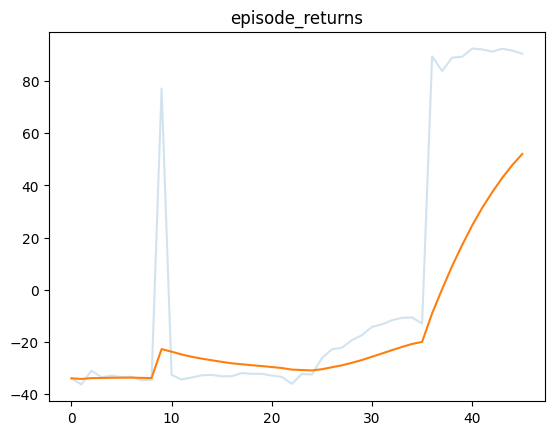

In [78]:
plt.plot(episode_returns, alpha=0.2)
plt.plot(smooth(episode_returns))
plt.title("episode_returns")
plt.show()

In [79]:
model_path = "A2C_network.pth"
torch.save(Actor.state_dict(), model_path)

In [80]:
envs_eval = gym.vector.SyncVectorEnv([lambda: make_env(env_id, True)])
eval_model = ActorNetwork(envs_eval).to(device)
eval_model.load_state_dict(torch.load(model_path, map_location=device))
eval_model.eval()

ActorNetwork(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
  )
  (mean_layer): Linear(in_features=256, out_features=1, bias=True)
  (log_sd_layer): Linear(in_features=256, out_features=1, bias=True)
)

In [81]:
n_episodes_eval = 10
eval_returns = np.zeros(n_episodes_eval)

for i in range(n_episodes_eval):
    obs, _ = envs_eval.reset()
    episode_reward_sum = 0.0  
    episode_done = False
    
    while not episode_done:
        # 1. obs is already batched by the vectorized env, so just convert to tensor
        obs_tensor = np2torch(obs).to(device)
        
        with torch.no_grad():
            logits = eval_model(obs_tensor)
            
            # 2. Get the best action, but KEEP it as a tensor (don't use .item())
            action = torch.argmax(logits, dim=-1)

        # 3. Convert the tensor to a numpy array (e.g., [2]) so the vector env can iterate over it
        action_np = action.cpu().numpy()

        next_obs, reward, terminated, truncated, infos = envs_eval.step(action_np)
        
        # 4. Because it's a vector env, reward, terminated, and truncated are ARRAYS. 
        # We grab the 0th index assuming your eval vector has 1 environment inside it.
        episode_reward_sum += reward[0]
        obs = next_obs
        
        if terminated[0] or truncated[0]:
            eval_returns[i] = episode_reward_sum
            print(f"Episode: {i + 1}/{n_episodes_eval}, Return: {episode_reward_sum}")
            episode_done = True

envs_eval.close()

print("-" * 30)
print(f"Average Evaluation Return: {np.mean(eval_returns):.2f} +/- {np.std(eval_returns):.2f}")

c:\Users\soseb\Documents\Robot-Arm-training-with-SAC\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


TypeError: argmax(): argument 'input' (position 1) must be Tensor, not tuple